# 03 — Compose: квадрат с круглым вырезом

Case: `cases/ci/compose_cutout.toml`; у compose аналитики нет — mms/fem/none (CASE_SCHEMA).

w_max = 5.1690e-06, cond(A) = 6.48e+02


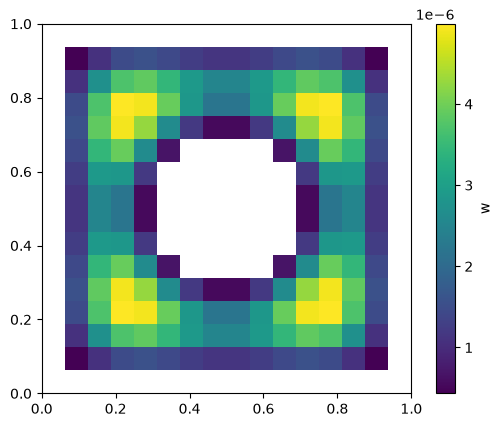

In [1]:
import matplotlib.pyplot as plt

from plate_solver.dispatch import solve
from plate_solver.problem import Problem

res = solve(Problem.from_toml("../cases/ci/compose_cutout.toml"))
print(f"w_max = {res.w_max:.4e}, cond(A) = {res.cond:.2e}")
plt.imshow(res.w_grid, origin="lower", extent=(0, 1, 0, 1))
plt.colorbar(label="w")

## Квартет (D3): 3D-прогиб · карта σ · контактный планшет · сходимость


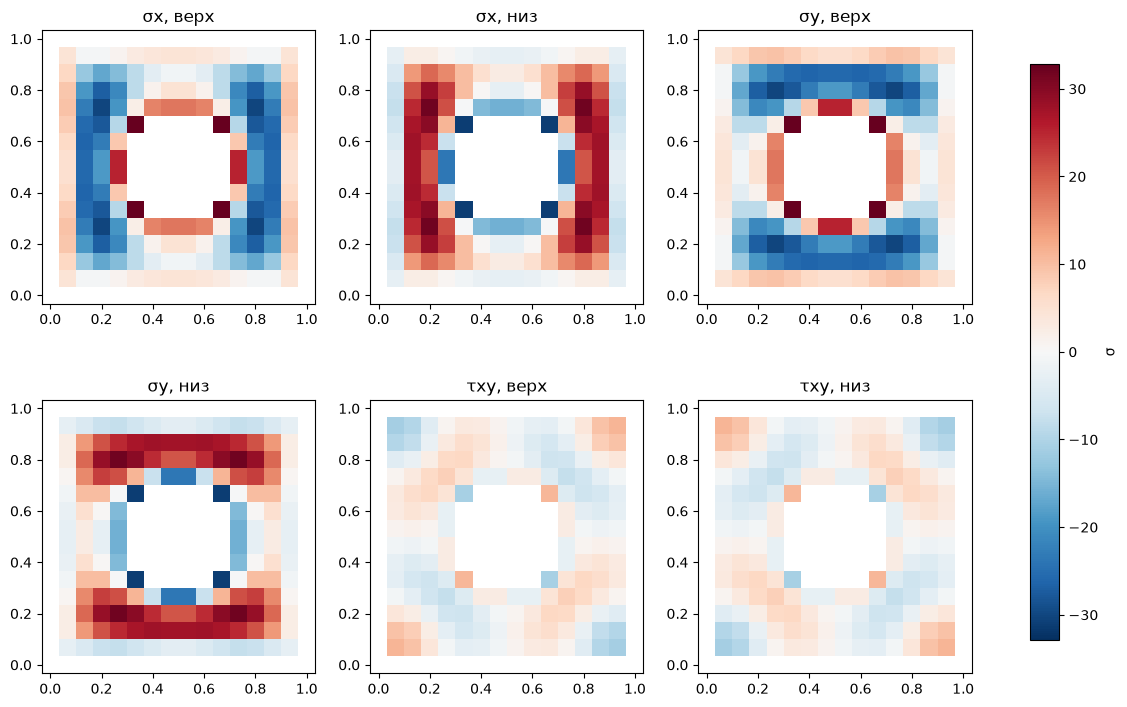

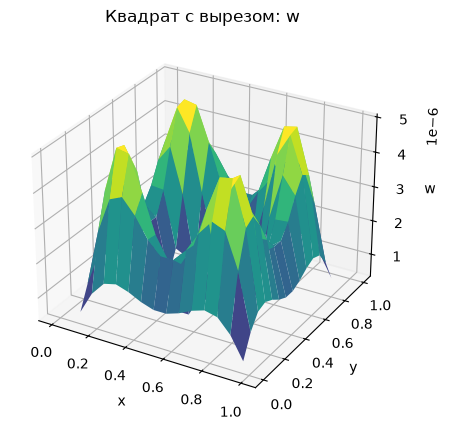

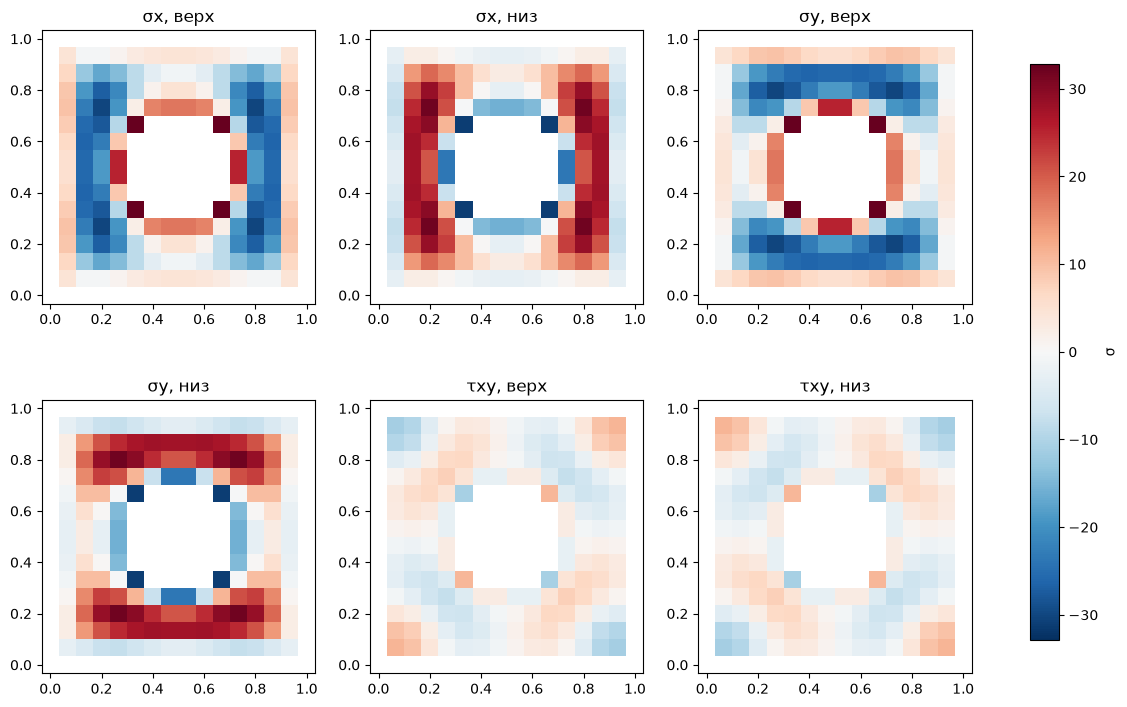

In [2]:

from plate_solver import viz
from plate_solver.ktn import stresses_faces

Mx, My, Mxy = res.moments_on_grid()
s = stresses_faces(Mx, My, Mxy, h=res.config.h, nu=res.config.nu, q_top=4.0)
viz.surface3d(res.Xg, res.Yg, res.w_grid, title="Квадрат с вырезом: w")
viz.stress_maps(res.Xg, res.Yg, s)   # NaN на изломах R-функций маскируются